In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys, os, re
from pathlib import Path
from typing import Optional
sys.path.append('../')

from src import *

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.size": 14,
#     "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
# })

seed = 42
np.random.seed(seed)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_parquet("../data/all_raman_spectra.parquet")
df = df.rename(columns={'group': 'animal'})

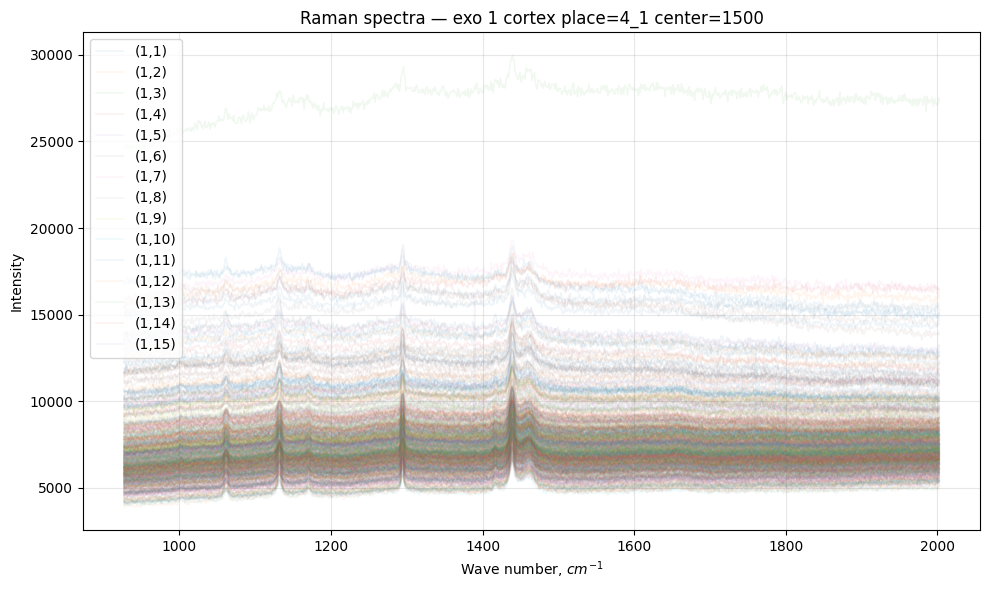

In [41]:
# 1. Из большого DataFrame — конкретные точки
plot_raman_spectra(
    df=df,
    label='exo',
    animal='1',
    center='1500',
    brain='cortex',
    place='4_1',
    # points=[(1, 1), (18, 8), (35, 15)],
    normalize=False,
)

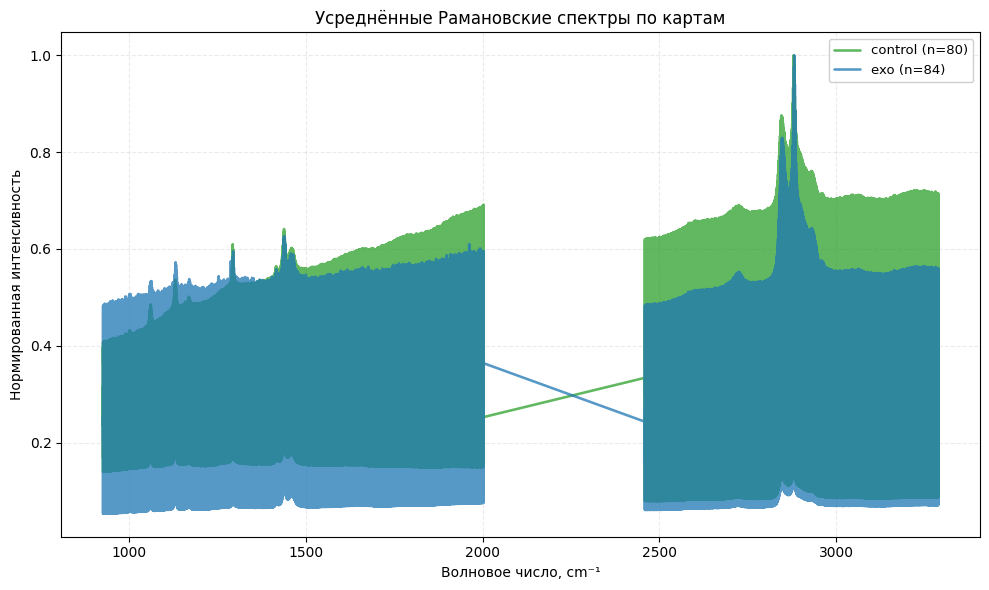

In [39]:
plot_avg_raman_spectra(avg_spectra, labels=['control', 'exo'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126291375 entries, 0 to 126291374
Data columns (total 9 columns):
 #   Column     Dtype   
---  ------     -----   
 0   X          float32 
 1   Y          float32 
 2   Wave       float32 
 3   Intensity  float32 
 4   label      category
 5   group      category
 6   center     category
 7   brain      category
 8   place      category
dtypes: category(5), float32(4)
memory usage: 2.5 GB


---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагаем, что df уже загружен
df['map_id_safe'] = (df['label'].astype(str) + '_' +
                     df['animal'].astype(str) + '_' + 
                     df['center'].astype(str) + '_' + 
                     df['brain'].astype(str) + '_' + 
                     df['place'].astype(str))

# Округляем Wave для быстрого усреднения (точность 0.01 обычно хватает для валидации)
df['Wave_rounded'] = df['Wave'].round(2)

# Усредняем Intensity по всем пикселям карты для каждого округлённого Wave
avg_spectra = (df.groupby(['map_id', 'Wave_rounded'])['Intensity']
               .mean()
               .reset_index())

print(f"Получено {avg_spectra['map_id'].nunique()} средних спектров (по одной карте)")

In [8]:
df.groupby('map_id')['label'].nunique().max()

np.int64(1)


  Обработка: 1500  |  спектров: 118

[0a] График исходных сырых спектров (нерегулярная сетка)…


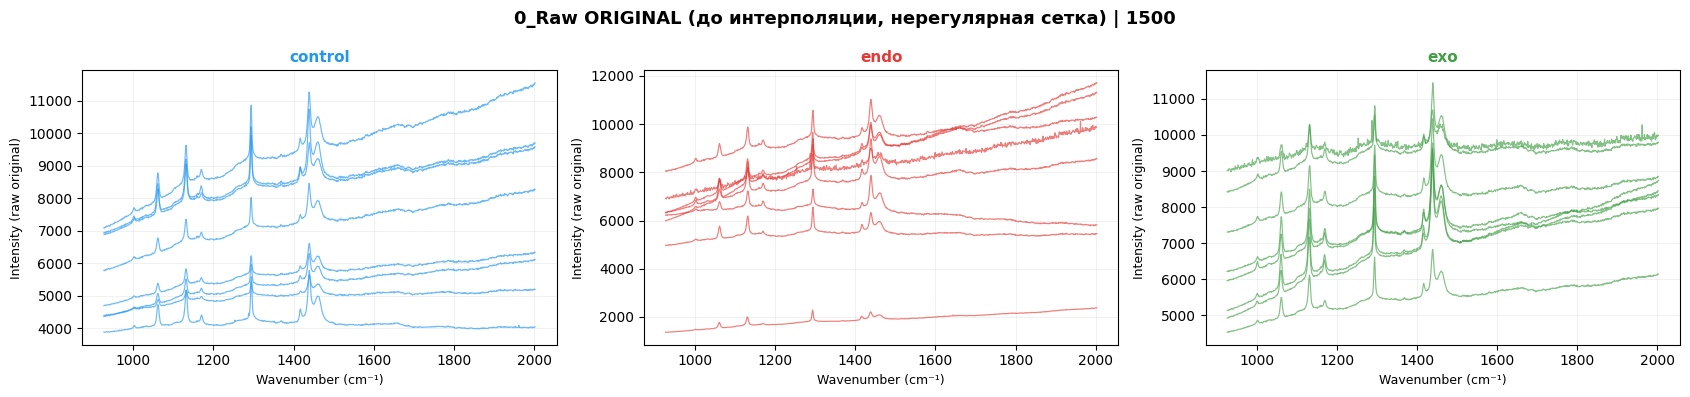

  → plots/1500_0_Raw_Original_preinterp.png

[0] Интерполяция на общую волновую сетку…
  Общий диапазон: [926.8, 2002.3] см⁻¹  →  1500 точек
  X.shape = (118, 1500)


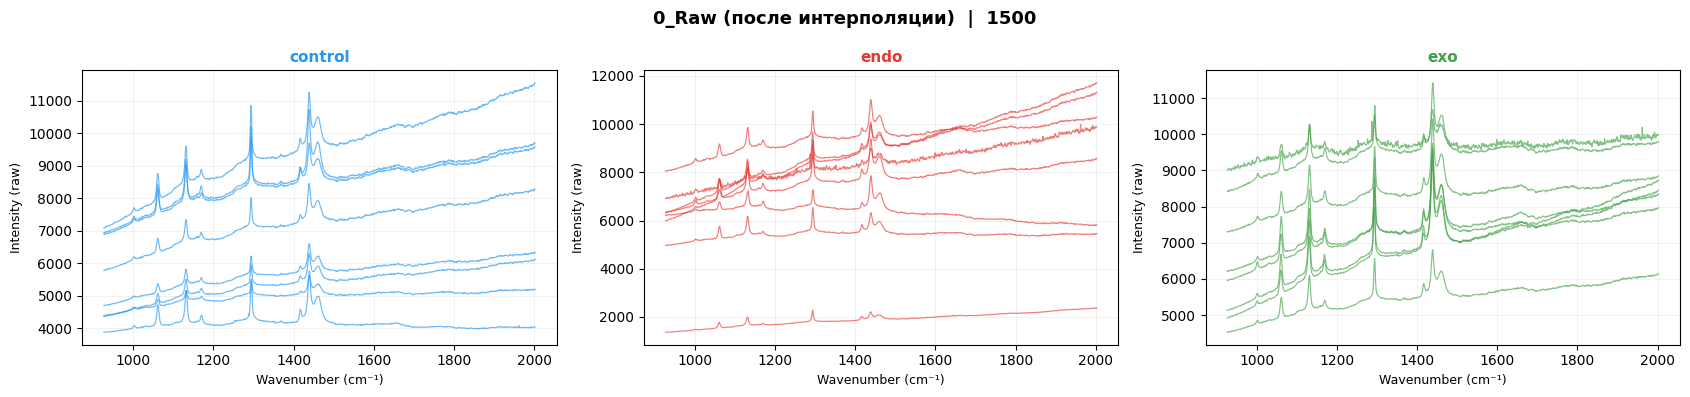

  → plots/1500_0_Raw_(после_интерполяции).png

[1] ALS Baseline (lam=1e+05, p=0.01)…


/tmp/ipykernel_136621/1262388339.py:109: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(W + H, w * y)


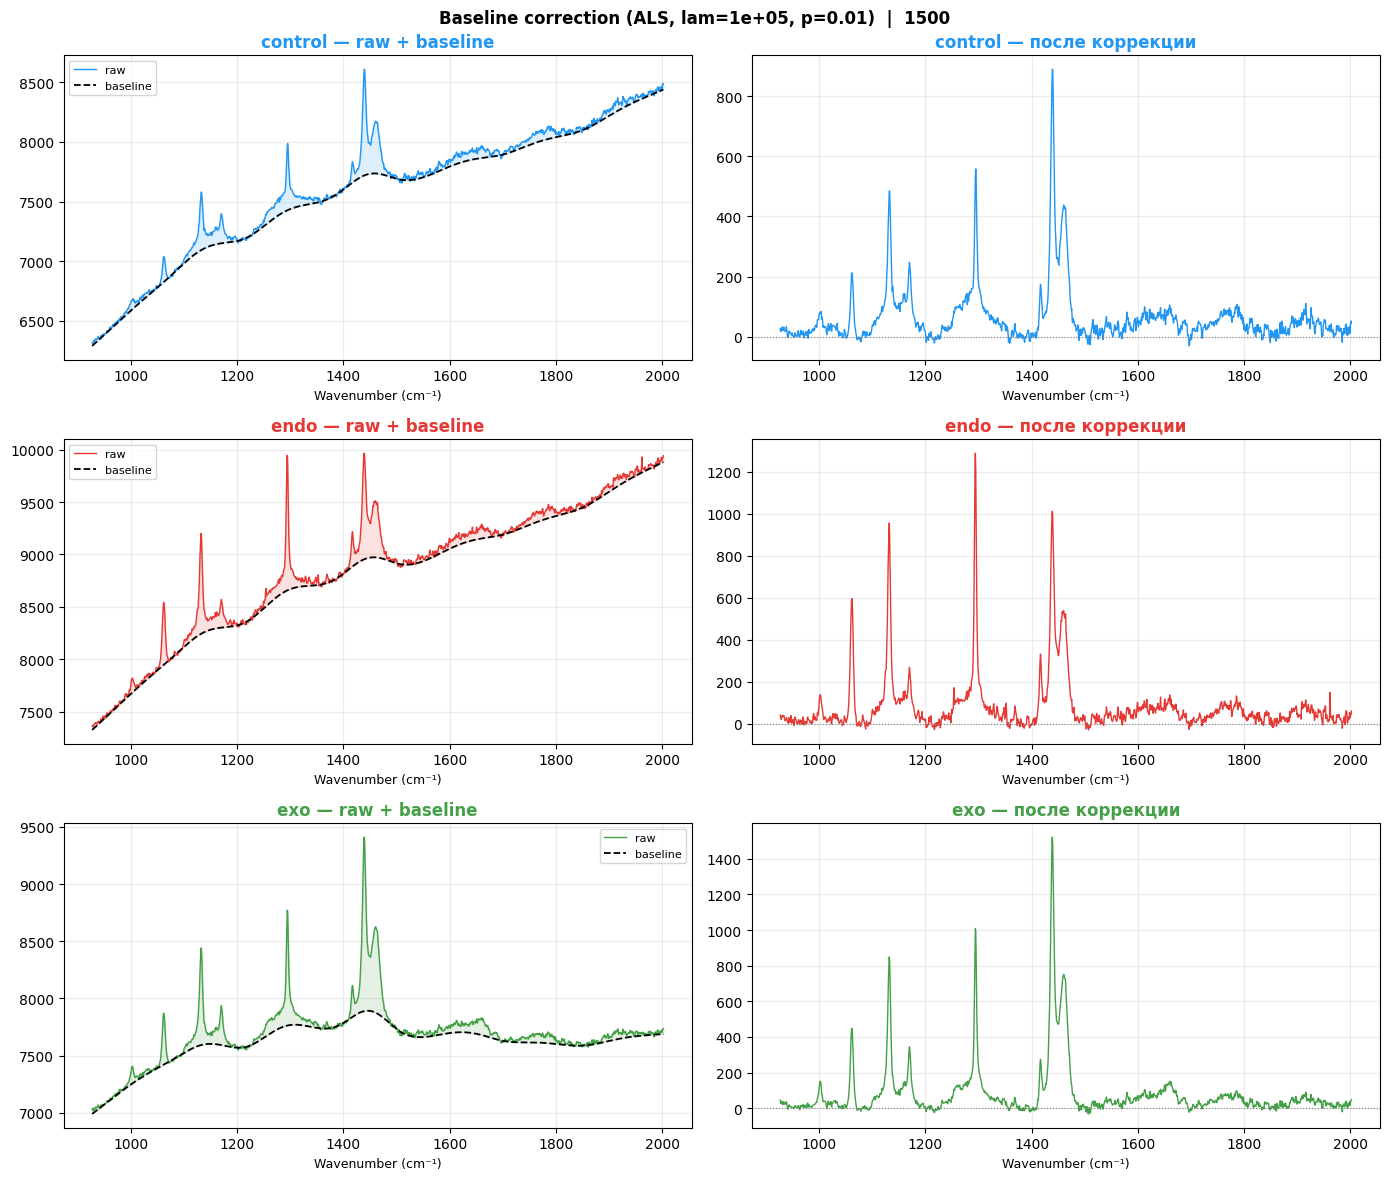

  → plots/1500_baseline_overlay.png


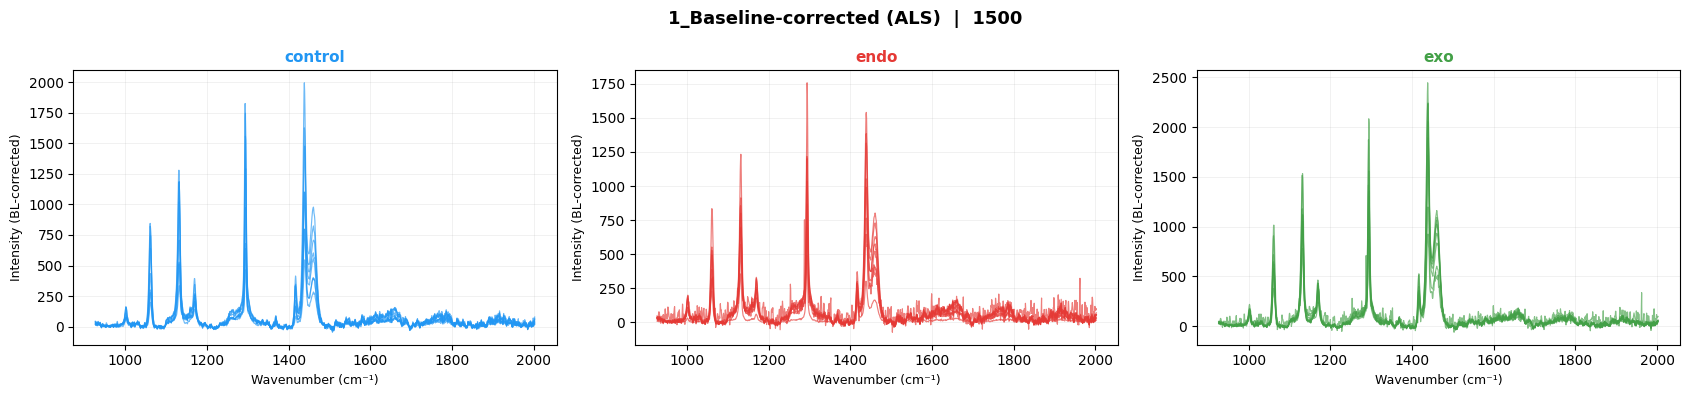

  → plots/1500_1_Baseline-corrected_(ALS).png

[2] Savitzky-Golay (w=11, p=3)…


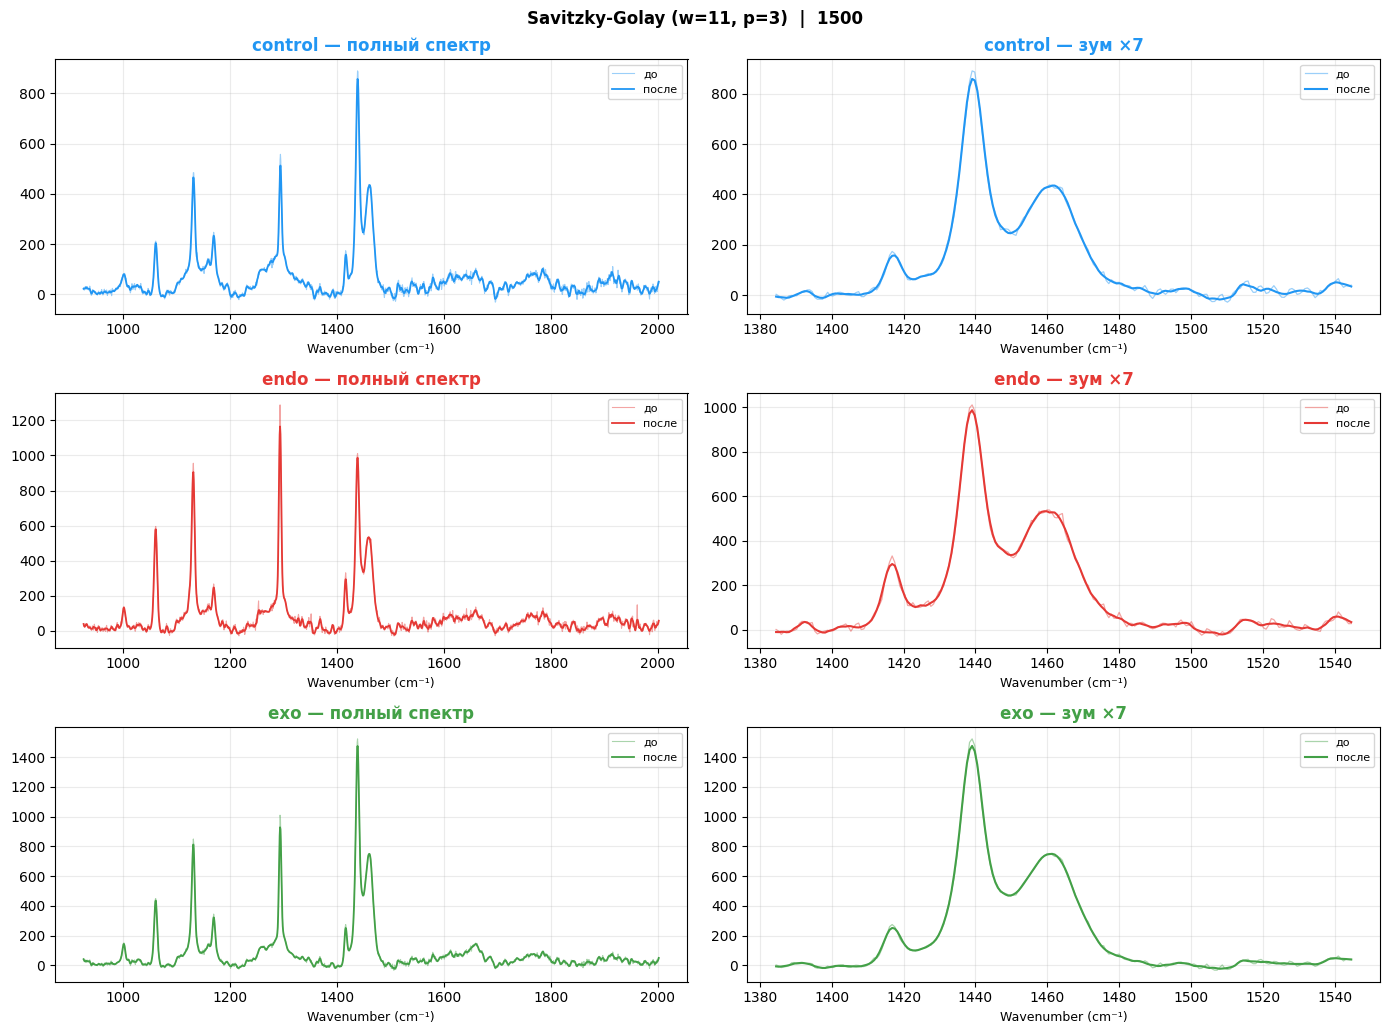

  → plots/1500_smoothing_zoom.png


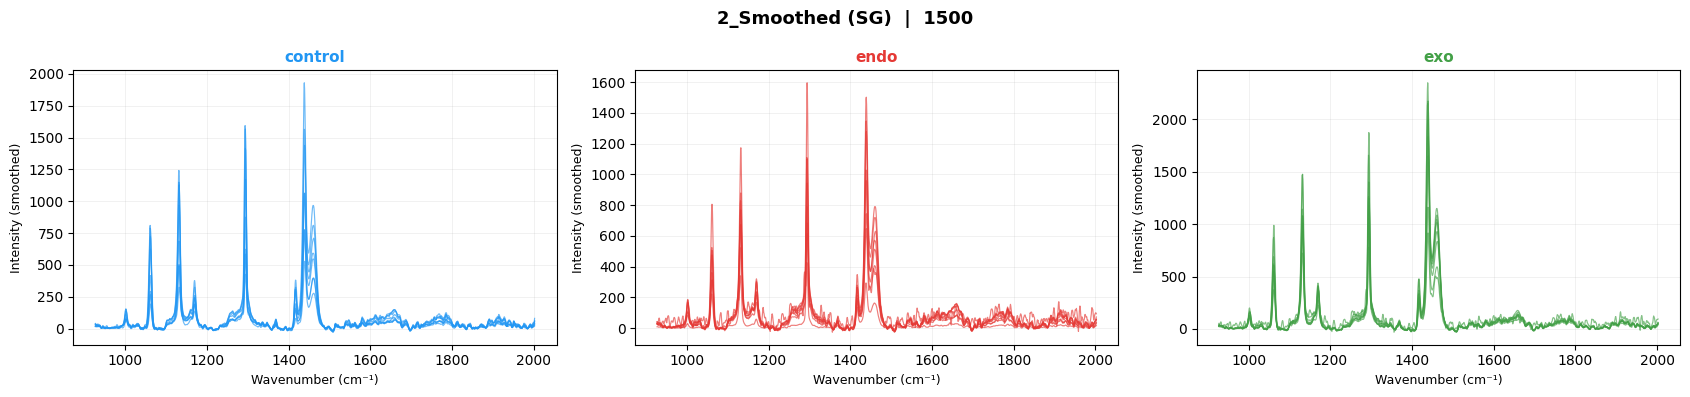

  → plots/1500_2_Smoothed_(SG).png

[3] Standard Normal Variate…


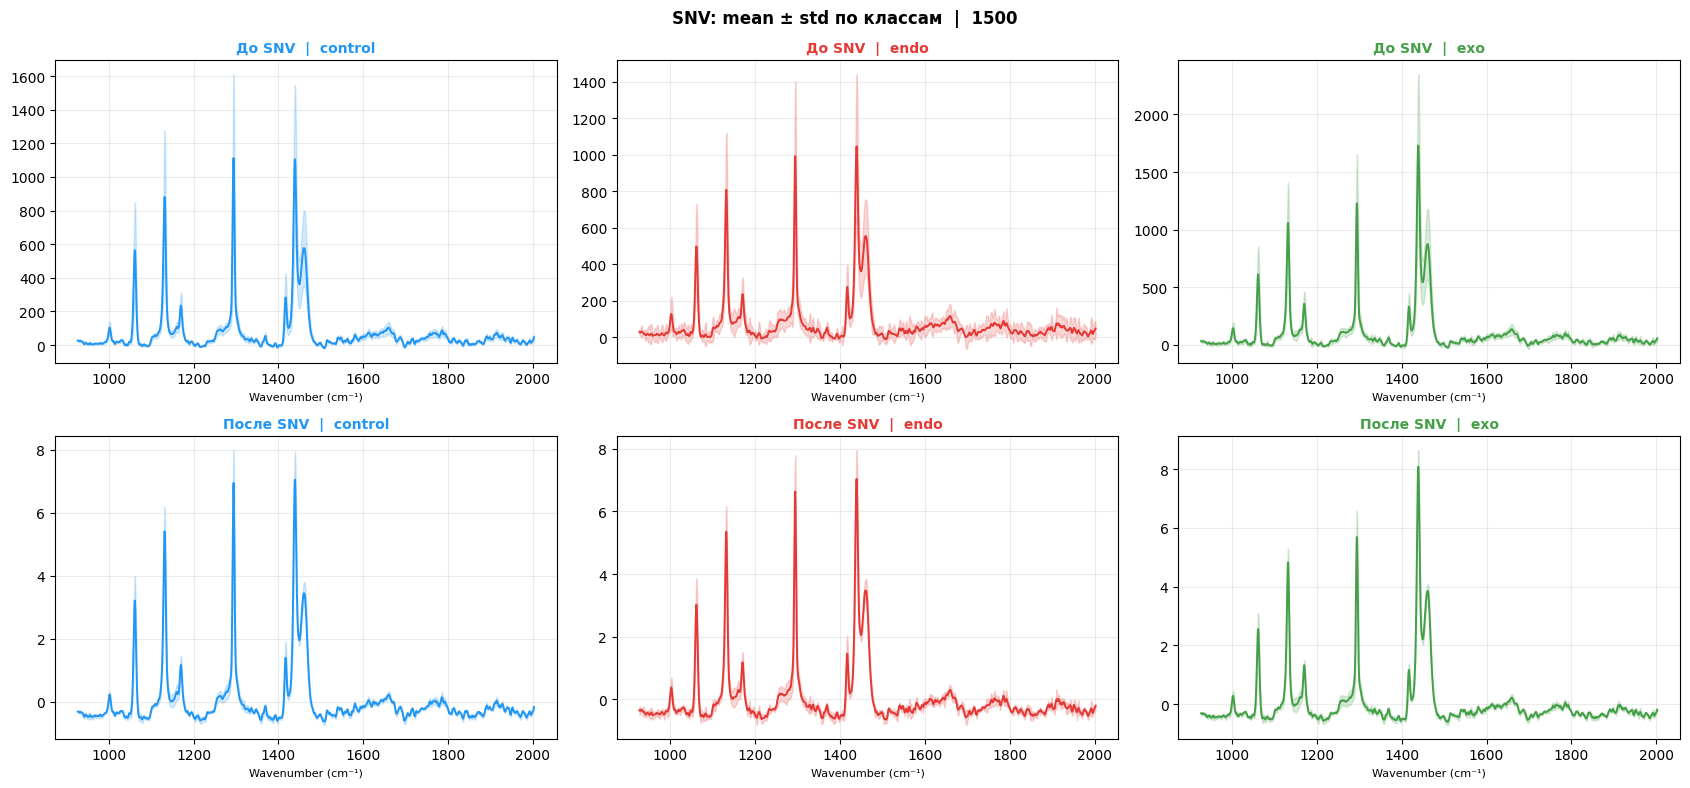

  → plots/1500_snv_comparison.png


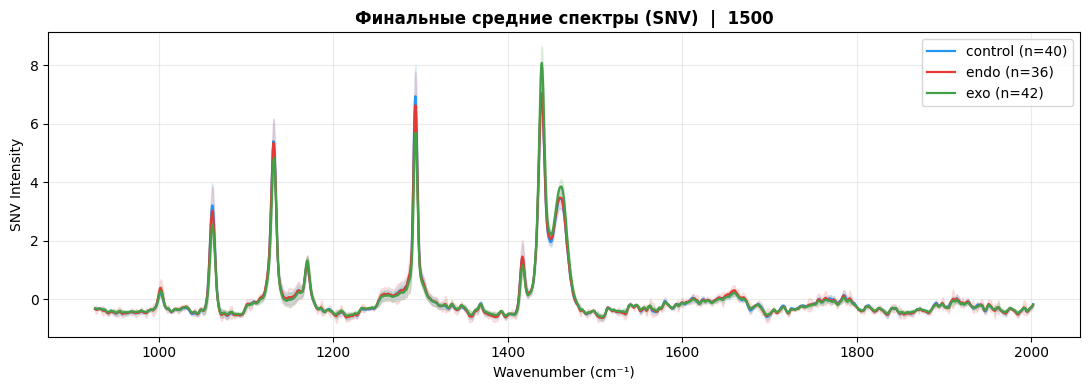

  → plots/1500_final_mean.png

✓ Готово: 1500   X.shape=(118, 1500)
  Классы:
label
exo        42
control    40
endo       36

  Обработка: 2900  |  спектров: 119

[0a] График исходных сырых спектров (нерегулярная сетка)…


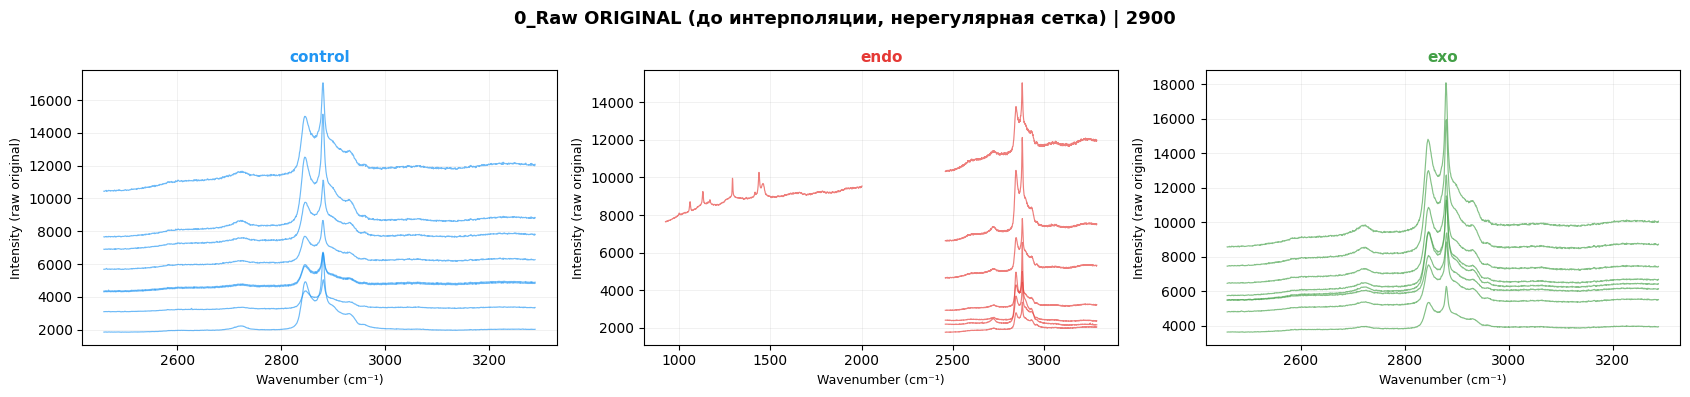

  → plots/2900_0_Raw_Original_preinterp.png

[0] Интерполяция на общую волновую сетку…
  Общий диапазон: [2459.0, 3288.1] см⁻¹  →  1500 точек
  X.shape = (119, 1500)


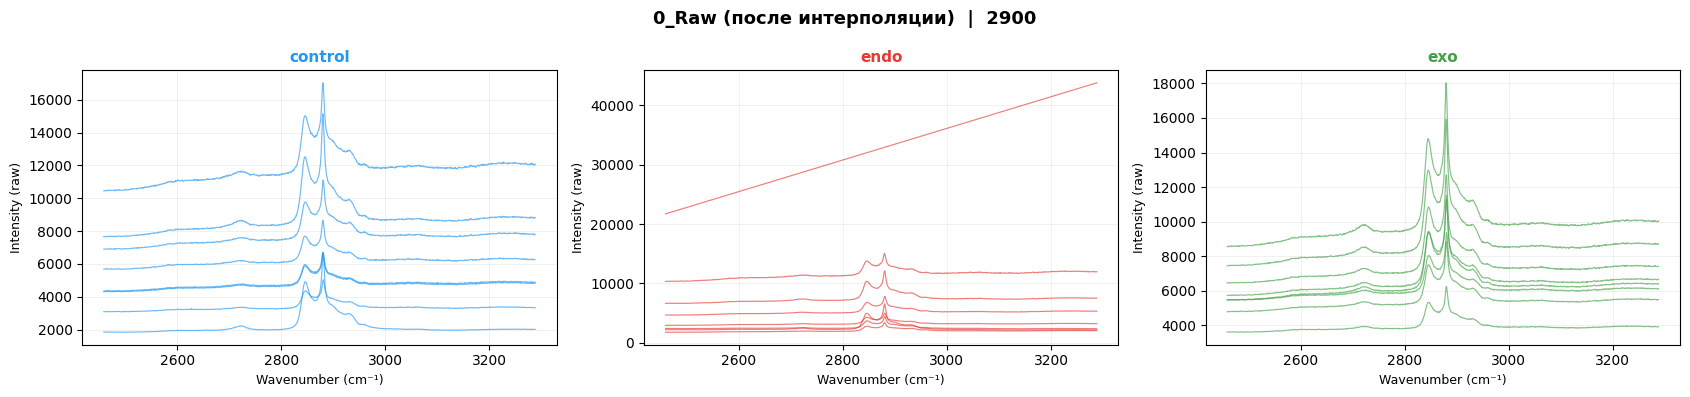

  → plots/2900_0_Raw_(после_интерполяции).png

[1] ALS Baseline (lam=1e+05, p=0.01)…


/tmp/ipykernel_136621/1262388339.py:109: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(W + H, w * y)


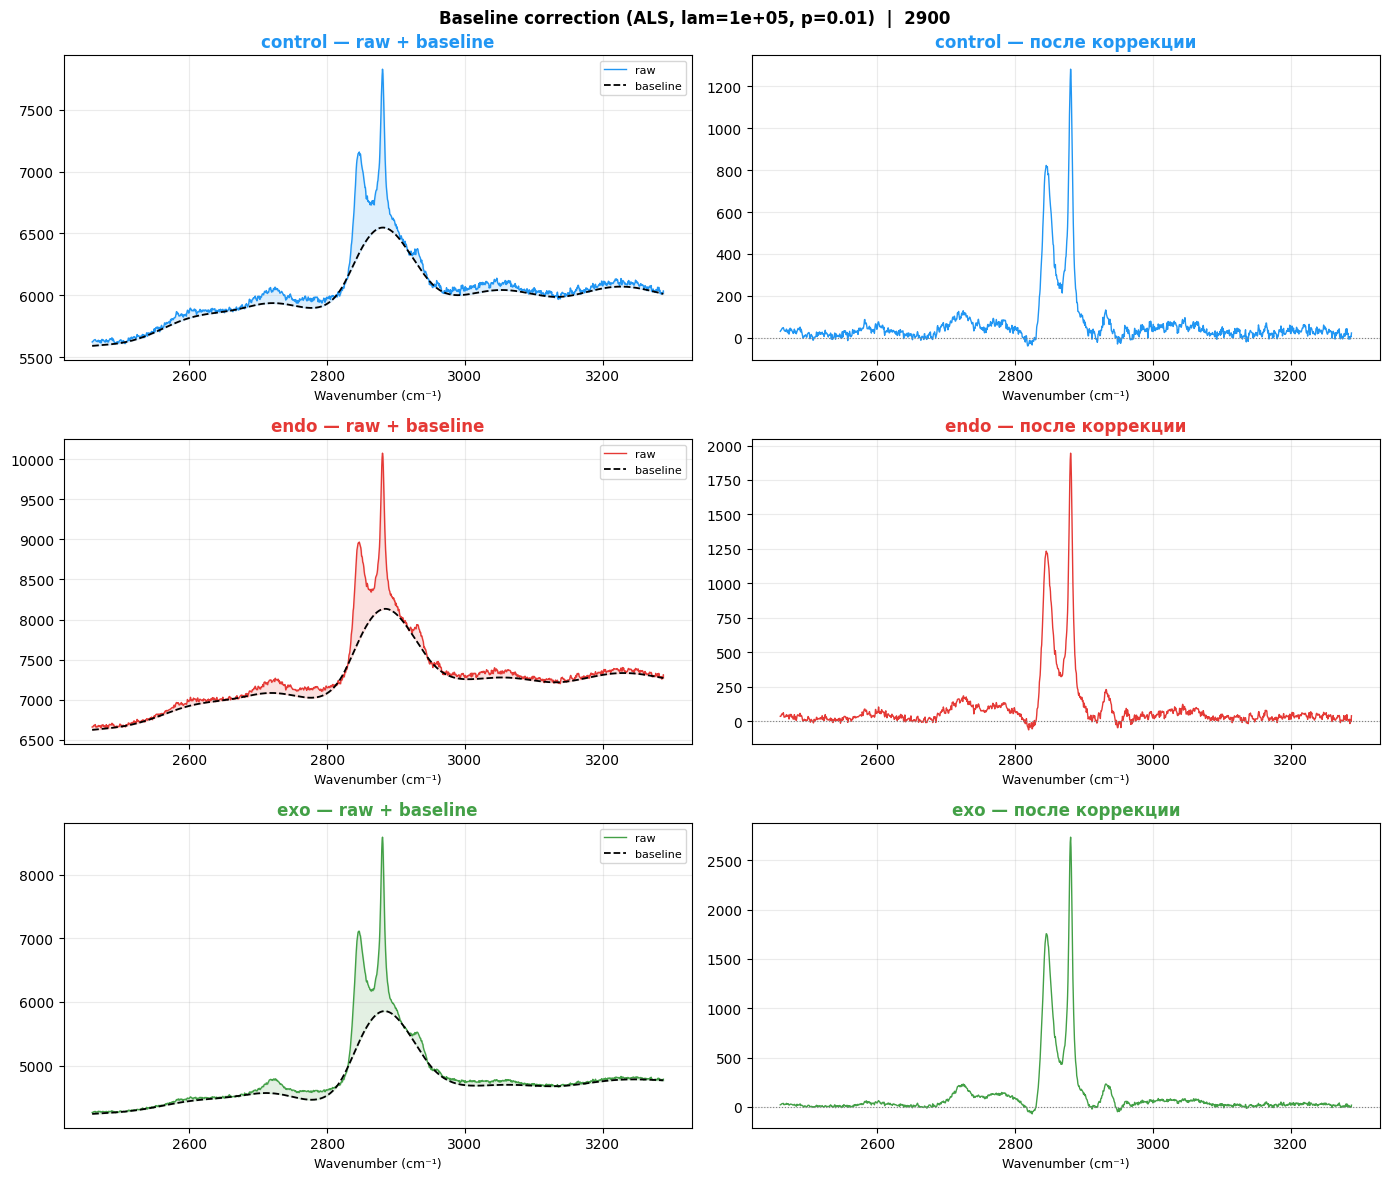

  → plots/2900_baseline_overlay.png


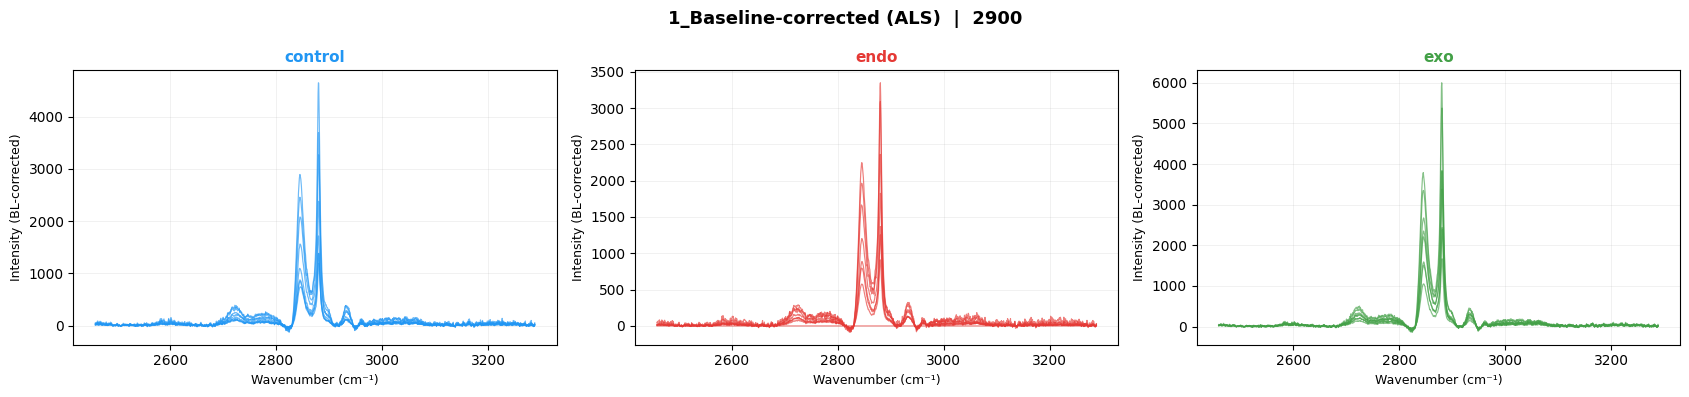

  → plots/2900_1_Baseline-corrected_(ALS).png

[2] Savitzky-Golay (w=11, p=3)…


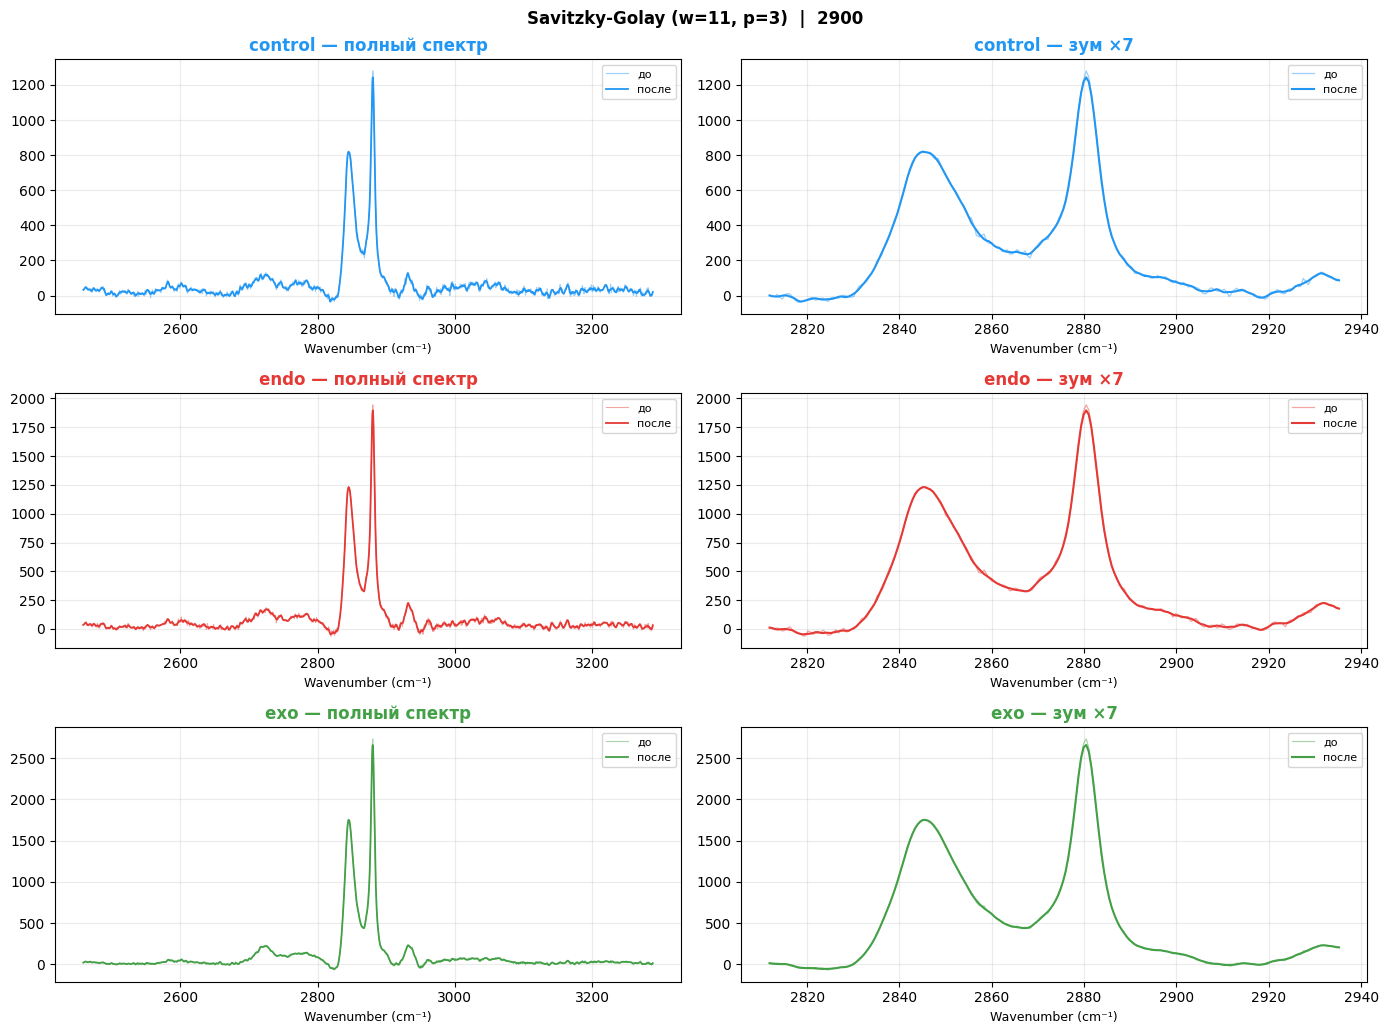

  → plots/2900_smoothing_zoom.png


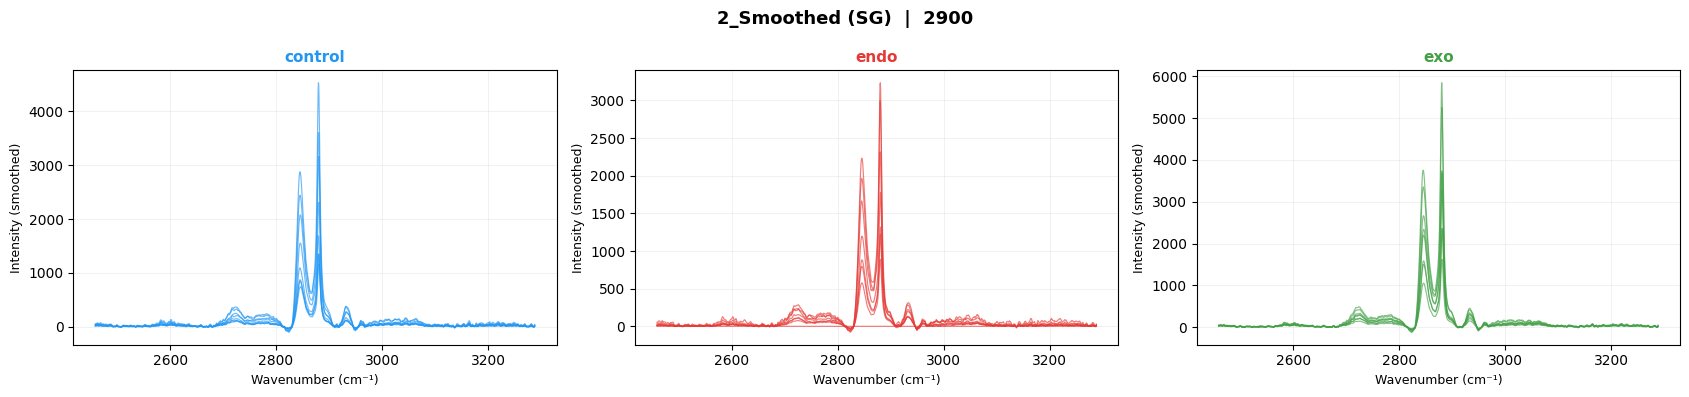

  → plots/2900_2_Smoothed_(SG).png

[3] Standard Normal Variate…


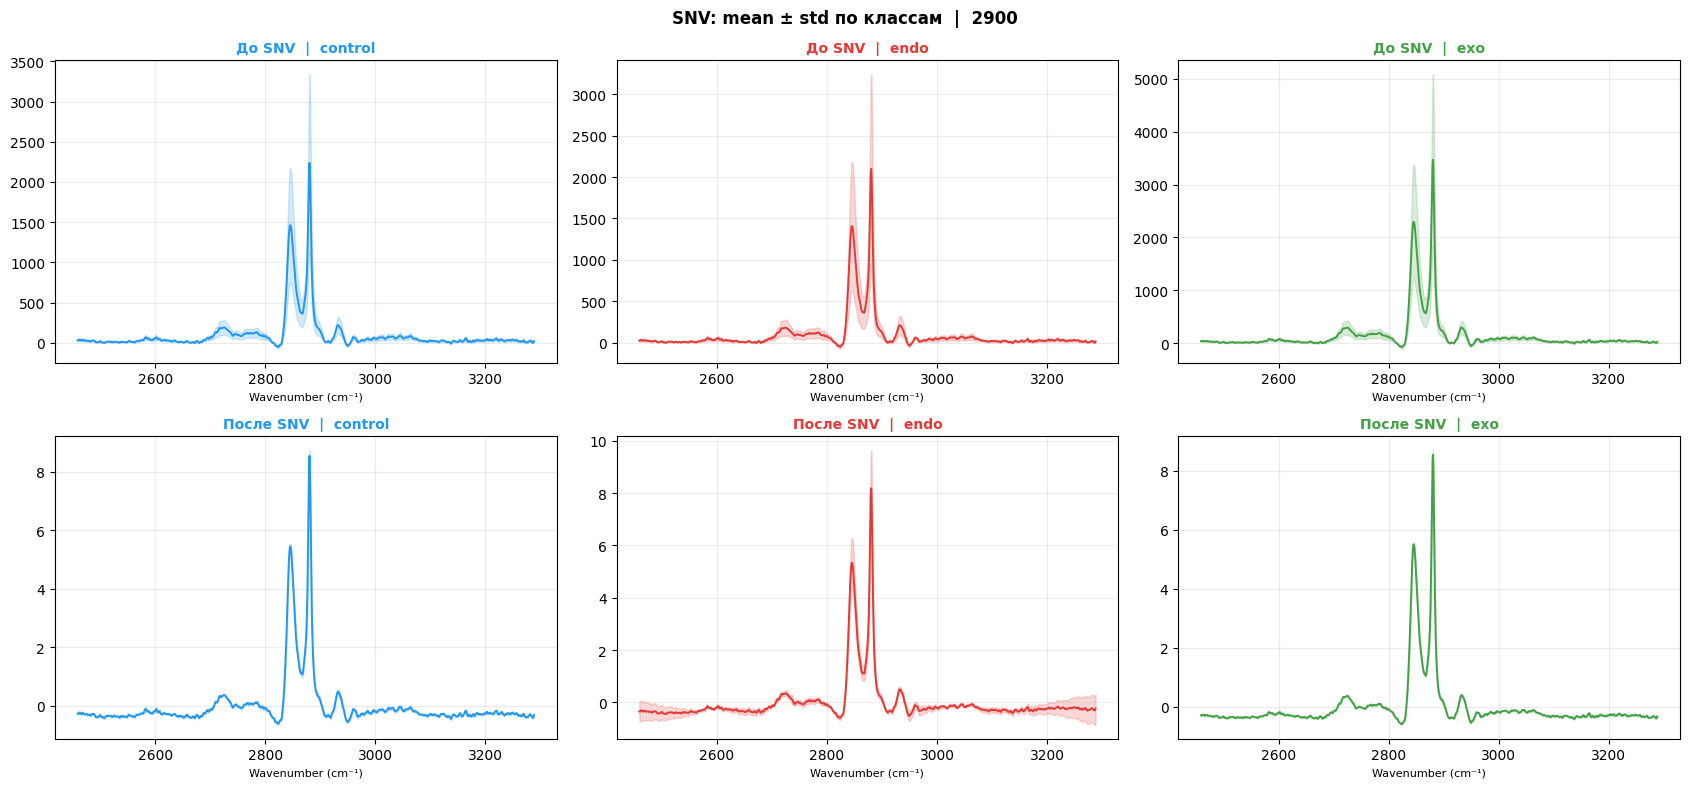

  → plots/2900_snv_comparison.png


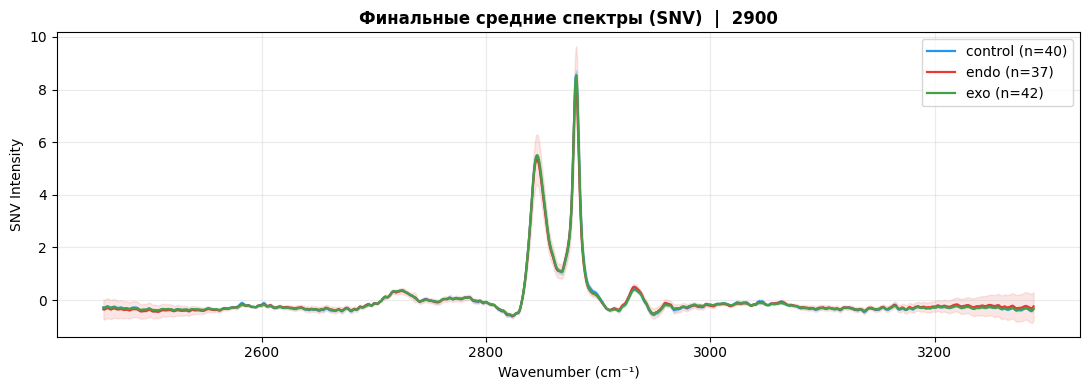

  → plots/2900_final_mean.png

✓ Готово: 2900   X.shape=(119, 1500)
  Классы:
label
exo        42
control    40
endo       37


In [9]:
"""
Raman Spectra Preprocessing Pipeline
=====================================
Этапы:
  0. Общая волновая сетка (интерполяция)
  1. Baseline correction — ALS (Asymmetric Least Squares)
  2. Smoothing           — Savitzky-Golay
  3. SNV                 — Standard Normal Variate

center1500 и center2900 обрабатываются независимо,
т.к. имеют разные диапазоны волновых чисел.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from pathlib import Path

# ──────────────────────────────────────────────────────────────
# Конфигурация
# ──────────────────────────────────────────────────────────────

LABEL_COLORS  = {'control': '#2196F3', 'endo': '#E53935', 'exo': '#43A047'}
LABEL_ORDER   = ['control', 'endo', 'exo']
N_PLOT        = 8           # спектров на класс на каждом графике
GRID_POINTS   = 1500        # точек в общей сетке

# ALS параметры
ALS_LAM  = 1e5              # гладкость базовой линии (10^4 – 10^6)
ALS_P    = 0.01             # асимметрия (0.001 – 0.05 для Рамана)
ALS_ITER = 15

# Savitzky-Golay параметры
SG_WINDOW    = 11           # нечётное число
SG_POLYORDER = 3

SAVE_DIR = Path("plots")
SAVE_DIR.mkdir(exist_ok=True)


# ──────────────────────────────────────────────────────────────
# 0. Общая волновая сетка + интерполяция
# ──────────────────────────────────────────────────────────────

def build_common_grid(group_df: pd.DataFrame,
                      n_points: int = GRID_POINTS,
                      clip_quantile: float = 0.02) -> np.ndarray:
    """
    Равномерная сетка на пересечении диапазонов всех спектров группы.
    clip_quantile: обрезает выбросы по Wave с обоих краёв.
    """
    ranges = group_df.groupby('map_id')['Wave_rounded'].agg(['min', 'max'])
    w_min = ranges['min'].quantile(1 - clip_quantile)
    w_max = ranges['max'].quantile(clip_quantile)
    print(f"  Общий диапазон: [{w_min:.1f}, {w_max:.1f}] см⁻¹  →  {n_points} точек")
    return np.linspace(w_min, w_max, n_points)


def interpolate_to_grid(group_df: pd.DataFrame,
                        common_grid: np.ndarray) -> tuple:
    """
    Линейная интерполяция каждого спектра на common_grid.
    Возвращает X (map_id × wave) и y (label).
    """
    rows, labels = {}, {}
    for mid, sub in group_df.groupby('map_id'):
        sub = sub.sort_values('Wave_rounded')
        wave      = sub['Wave_rounded'].values
        intensity = sub['Intensity'].values

        # Убираем дубликаты (коллизии округления)
        wave, idx = np.unique(wave, return_index=True)
        intensity = intensity[idx]

        f = interp1d(wave, intensity, kind='linear',
                     bounds_error=False, fill_value='extrapolate')
        rows[mid]   = f(common_grid)
        labels[mid] = sub['label'].iloc[0]

    X = pd.DataFrame(rows, index=common_grid).T
    X.index.name = 'map_id'
    y = pd.Series(labels, name='label')
    return X, y


# ──────────────────────────────────────────────────────────────
# 1. Baseline Correction — ALS
# ──────────────────────────────────────────────────────────────

def _als_baseline(y: np.ndarray,
                  lam: float = ALS_LAM,
                  p: float   = ALS_P,
                  niter: int = ALS_ITER) -> np.ndarray:
    """
    Asymmetric Least Squares (Eilers & Boelens, 2005).
    lam — сглаженность; p — насколько baseline прижат снизу.
    """
    L = len(y)
    D = diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
    H = lam * D.T @ D
    w = np.ones(L)
    z = y.copy()
    for _ in range(niter):
        W = diags(w, 0, shape=(L, L))
        z = spsolve(W + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z


def apply_baseline_correction(X: pd.DataFrame,
                               lam: float = ALS_LAM,
                               p: float   = ALS_P) -> tuple:
    """Возвращает (X_corrected, X_baselines)."""
    corrected = np.empty_like(X.values)
    baselines = np.empty_like(X.values)
    for i, row in enumerate(X.values):
        bl = _als_baseline(row, lam=lam, p=p)
        baselines[i] = bl
        corrected[i] = row - bl
    X_corr = pd.DataFrame(corrected, index=X.index, columns=X.columns)
    X_bl   = pd.DataFrame(baselines, index=X.index, columns=X.columns)
    return X_corr, X_bl


# ──────────────────────────────────────────────────────────────
# 2. Smoothing — Savitzky-Golay
# ──────────────────────────────────────────────────────────────

def apply_smoothing(X: pd.DataFrame,
                    window_length: int = SG_WINDOW,
                    polyorder: int     = SG_POLYORDER) -> pd.DataFrame:
    smoothed = savgol_filter(X.values,
                             window_length=window_length,
                             polyorder=polyorder,
                             axis=1)
    return pd.DataFrame(smoothed, index=X.index, columns=X.columns)


# ──────────────────────────────────────────────────────────────
# 3. SNV — Standard Normal Variate
# ──────────────────────────────────────────────────────────────

def apply_snv(X: pd.DataFrame) -> pd.DataFrame:
    """
    Для каждого спектра: (x - mean(x)) / std(x).
    Убирает мультипликативные эффекты рассеяния.
    """
    mean = X.mean(axis=1)
    std  = X.std(axis=1).replace(0, 1)
    return X.sub(mean, axis=0).div(std, axis=0)


# ──────────────────────────────────────────────────────────────
# Валидационные графики
# ──────────────────────────────────────────────────────────────

def _sample_ids(y: pd.Series, n: int = N_PLOT) -> dict:
    rng = np.random.default_rng(42)
    return {
        lbl: rng.choice(y[y == lbl].index,
                        size=min(n, (y == lbl).sum()),
                        replace=False)
        for lbl in LABEL_ORDER if (y == lbl).sum() > 0
    }


def plot_all_classes(X, y, wave, title, center_name, n=N_PLOT, ylabel='Intensity'):
    """Три панели (по классу), n спектров каждый."""
    sample = _sample_ids(y, n)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
    fig.suptitle(f'{title}  |  {center_name}', fontsize=13, fontweight='bold')
    for ax, lbl in zip(axes, LABEL_ORDER):
        if lbl not in sample:
            ax.set_visible(False); continue
        for mid in sample[lbl]:
            ax.plot(wave, X.loc[mid].values,
                    alpha=0.65, lw=0.85, color=LABEL_COLORS[lbl])
        ax.set_title(lbl, color=LABEL_COLORS[lbl], fontweight='bold', fontsize=11)
        ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.25, lw=0.5)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_{title[:30].replace(" ","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  → {fname}")


def plot_raw_original(group_df: pd.DataFrame,
                      center_name: str,
                      n: int = N_PLOT):
    """
    График ИСХОДНЫХ сырых спектров ДО интерполяции.
    Каждый спектр рисуется на своей собственной (нерегулярной) сетке Wave_rounded.
    """
    # label per map_id
    label_map = group_df.groupby('map_id')['label'].first()

    sample = _sample_ids(label_map, n)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
    fig.suptitle(f'0_Raw ORIGINAL (до интерполяции, нерегулярная сетка) | {center_name}',
                 fontsize=13, fontweight='bold')
    for ax, lbl in zip(axes, LABEL_ORDER):
        if lbl not in sample:
            ax.set_visible(False)
            continue
        for mid in sample[lbl]:
            sub = group_df[group_df['map_id'] == mid].sort_values('Wave_rounded')
            ax.plot(sub['Wave_rounded'], sub['Intensity'],
                    alpha=0.65, lw=0.85, color=LABEL_COLORS[lbl])
        ax.set_title(lbl, color=LABEL_COLORS[lbl], fontweight='bold', fontsize=11)
        ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
        ax.set_ylabel('Intensity (raw original)', fontsize=9)
        ax.grid(True, alpha=0.25, lw=0.5)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_0_Raw_Original_preinterp.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  → {fname}")


def plot_baseline_overlay(X_raw, X_bl, X_corr, y, wave, center_name):
    """Для одного спектра каждого класса: raw+baseline и результат."""
    sample = {lbl: y[y == lbl].index[0] for lbl in LABEL_ORDER if (y == lbl).sum() > 0}
    fig, axes = plt.subplots(len(sample), 2, figsize=(14, 4 * len(sample)))
    fig.suptitle(f'Baseline correction (ALS, lam={ALS_LAM:.0e}, p={ALS_P})  |  {center_name}',
                 fontsize=12, fontweight='bold')
    for row, (lbl, mid) in enumerate(sample.items()):
        c = LABEL_COLORS[lbl]
        ax_l, ax_r = axes[row]
        ax_l.plot(wave, X_raw.loc[mid].values,  color=c,       lw=1,   label='raw')
        ax_l.plot(wave, X_bl.loc[mid].values,   color='black', lw=1.3,
                  ls='--', label='baseline')
        ax_l.fill_between(wave, X_bl.loc[mid].values, X_raw.loc[mid].values,
                           alpha=0.15, color=c)
        ax_l.set_title(f'{lbl} — raw + baseline', fontweight='bold', color=c)
        ax_l.legend(fontsize=8); ax_l.grid(True, alpha=0.25)
        ax_l.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)

        ax_r.plot(wave, X_corr.loc[mid].values, color=c, lw=1)
        ax_r.axhline(0, color='grey', lw=0.8, ls=':')
        ax_r.set_title(f'{lbl} — после коррекции', fontweight='bold', color=c)
        ax_r.grid(True, alpha=0.25)
        ax_r.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_baseline_overlay.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  → {fname}")


def plot_smoothing_zoom(X_before, X_after, y, wave, center_name, zoom_frac=0.15):
    """Полный спектр и зум на средний участок — для оценки сглаживания."""
    n_z = max(2, int(len(wave) * zoom_frac))
    mid = len(wave) // 2
    slc = slice(mid - n_z // 2, mid + n_z // 2)
    sample = {lbl: y[y == lbl].index[0] for lbl in LABEL_ORDER if (y == lbl).sum() > 0}
    fig, axes = plt.subplots(len(sample), 2, figsize=(14, 3.5 * len(sample)))
    fig.suptitle(f'Savitzky-Golay (w={SG_WINDOW}, p={SG_POLYORDER})  |  {center_name}',
                 fontsize=12, fontweight='bold')
    for row, (lbl, map_id) in enumerate(sample.items()):
        c = LABEL_COLORS[lbl]
        vb, va = X_before.loc[map_id].values, X_after.loc[map_id].values
        ax_l, ax_r = axes[row]
        ax_l.plot(wave, vb, alpha=0.45, lw=0.8, color=c, label='до')
        ax_l.plot(wave, va, lw=1.3, color=c, label='после')
        ax_l.set_title(f'{lbl} — полный спектр', fontweight='bold', color=c)
        ax_l.legend(fontsize=8); ax_l.grid(True, alpha=0.25)
        ax_l.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
        ax_r.plot(wave[slc], vb[slc], alpha=0.45, lw=0.9, color=c, label='до')
        ax_r.plot(wave[slc], va[slc], lw=1.5, color=c, label='после')
        ax_r.set_title(f'{lbl} — зум ×{1/zoom_frac:.0f}', fontweight='bold', color=c)
        ax_r.legend(fontsize=8); ax_r.grid(True, alpha=0.25)
        ax_r.set_xlabel('Wavenumber (cm⁻¹)', fontsize=9)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_smoothing_zoom.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  → {fname}")


def plot_snv_comparison(X_before, X_after, y, wave, center_name):
    """Mean ± std по классам до и после SNV."""
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle(f'SNV: mean ± std по классам  |  {center_name}',
                 fontsize=12, fontweight='bold')
    for col, (stage_name, X) in enumerate([('До SNV', X_before), ('После SNV', X_after)]):
        for row, lbl in enumerate(LABEL_ORDER):
            ax = axes[col, row]
            ids = y[y == lbl].index
            if len(ids) == 0: ax.set_visible(False); continue
            mat = X.loc[ids].values
            mu, sd = mat.mean(0), mat.std(0)
            c = LABEL_COLORS[lbl]
            ax.plot(wave, mu, color=c, lw=1.4)
            ax.fill_between(wave, mu - sd, mu + sd, alpha=0.20, color=c)
            ax.set_title(f'{stage_name}  |  {lbl}', fontweight='bold', color=c, fontsize=10)
            ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=8)
            ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_snv_comparison.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  → {fname}")


def plot_final_mean(X, y, wave, center_name):
    """Итоговые средние спектры трёх классов на одной оси."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for lbl in LABEL_ORDER:
        ids = y[y == lbl].index
        if len(ids) == 0: continue
        mu = X.loc[ids].values.mean(0)
        sd = X.loc[ids].values.std(0)
        ax.plot(wave, mu, color=LABEL_COLORS[lbl], lw=1.6, label=f'{lbl} (n={len(ids)})')
        ax.fill_between(wave, mu - sd, mu + sd, alpha=0.12, color=LABEL_COLORS[lbl])
    ax.set_title(f'Финальные средние спектры (SNV)  |  {center_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('SNV Intensity')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fname = SAVE_DIR / f'{center_name}_final_mean.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight'); plt.show()
    print(f"  → {fname}")


# ──────────────────────────────────────────────────────────────
# Главный пайплайн для одной группы center
# ──────────────────────────────────────────────────────────────

def preprocess_center(avg_spectra: pd.DataFrame,
                      center_name: str) -> tuple:
    """
    Полный пайплайн предобработки для одного диапазона...
    """
    print(f"\n{'='*60}")
    print(f"  Обработка: {center_name}  |  "
          f"спектров: {avg_spectra['map_id'].nunique()}")
    print(f"{'='*60}")

    # ──────────────────────────────────────────────────────────────
    # NEW: График ИСХОДНЫХ данных ДО интерполяции
    # ──────────────────────────────────────────────────────────────
    print("\n[0a] График исходных сырых спектров (нерегулярная сетка)…")
    plot_raw_original(avg_spectra, center_name)

    # 0. Общая сетка + интерполяция
    print("\n[0] Интерполяция на общую волновую сетку…")
    wave = build_common_grid(avg_spectra)
    X_raw, y = interpolate_to_grid(avg_spectra, wave)
    print(f"  X.shape = {X_raw.shape}")
    plot_all_classes(X_raw, y, wave,
                     title='0_Raw (после интерполяции)',
                     center_name=center_name, ylabel='Intensity (raw)')
    
    # 1. ALS Baseline correction
    print(f"\n[1] ALS Baseline (lam={ALS_LAM:.0e}, p={ALS_P})…")
    X_corr, X_bl = apply_baseline_correction(X_raw)
    plot_baseline_overlay(X_raw, X_bl, X_corr, y, wave, center_name)
    plot_all_classes(X_corr, y, wave,
                     title='1_Baseline-corrected (ALS)',
                     center_name=center_name, ylabel='Intensity (BL-corrected)')

    # 2. Savitzky-Golay smoothing
    print(f"\n[2] Savitzky-Golay (w={SG_WINDOW}, p={SG_POLYORDER})…")
    X_smooth = apply_smoothing(X_corr)
    plot_smoothing_zoom(X_corr, X_smooth, y, wave, center_name)
    plot_all_classes(X_smooth, y, wave,
                     title='2_Smoothed (SG)',
                     center_name=center_name, ylabel='Intensity (smoothed)')

    # 3. SNV
    print("\n[3] Standard Normal Variate…")
    X_snv = apply_snv(X_smooth)
    plot_snv_comparison(X_smooth, X_snv, y, wave, center_name)
    plot_final_mean(X_snv, y, wave, center_name)

    print(f"\n✓ Готово: {center_name}   X.shape={X_snv.shape}")
    print(f"  Классы:\n{y.value_counts().to_string()}")

    return X_snv, y, wave


# ──────────────────────────────────────────────────────────────
# Точка входа
# ──────────────────────────────────────────────────────────────

def run_preprocessing(avg_spectra: pd.DataFrame) -> dict:
    """
    Запускает пайплайн для каждого center независимо.

    Ожидает колонки: map_id, Wave_rounded, Intensity, label, center

    Возвращает словарь:
        { 'center1500': (X, y, wave), 'center2900': (X, y, wave) }
    """
    results = {}
    for center_val, group in avg_spectra.groupby('center'):
        grp = group.drop(columns=['center'])
        X, y, wave = preprocess_center(grp, center_name=str(center_val))
        results[str(center_val)] = (X, y, wave)
    return results


# ──────────────────────────────────────────────────────────────
avg_spectra = (
    df.groupby(['map_id', 'Wave_rounded', 'label', 'center'])['Intensity']
      .mean()
      .reset_index()
)

results = run_preprocessing(avg_spectra)
X_1500, y_1500, wave_1500 = results['1500']
X_2900, y_2900, wave_2900 = results['2900']

# Объединить оба диапазона в одну матрицу признаков (если нужно):
# (убедитесь, что индексы map_id совпадают)
X_combined = pd.concat([X_1500, X_2900], axis=1)

In [54]:
X_combined

,926.830017,927.547462,928.264907,928.982352,929.699797,930.417242,931.134687,931.852132,932.569577,933.287022,...,3283.132068,3283.685184,3284.238299,3284.791414,3285.344530,3285.897645,3286.450761,3287.003876,3287.556992,3288.110107
map_id,,,,,,,,,,,,,,,,,,,,,
control_1_1500_cortex_4_1,-0.421913,-0.418108,-0.414037,-0.409400,-0.403898,-0.397229,-0.369347,-0.361729,-0.374939,-0.386995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
control_1_1500_cortex_4_2,-0.349387,-0.387441,-0.421929,-0.451069,-0.473079,-0.486175,-0.460331,-0.446703,-0.450630,-0.454836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
control_1_1500_cortex_5_1,-0.369849,-0.343358,-0.334328,-0.337266,-0.346676,-0.357064,-0.339758,-0.327012,-0.324173,-0.324366,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
control_1_1500_cortex_5_2,-0.345518,-0.313995,-0.302487,-0.305897,-0.319127,-0.337080,-0.336398,-0.346009,-0.363126,-0.369933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
control_1_1500_cortex_6_1,-0.347693,-0.341139,-0.339028,-0.339465,-0.340559,-0.340414,-0.317478,-0.306050,-0.308808,-0.311980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
exo_3_2900_cerebellum_right_1_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.325592,-0.334296,-0.344467,-0.351516,-0.358167,-0.361962,-0.361044,-0.353890,-0.338975,-0.314774
exo_3_2900_cerebellum_right_2_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.313623,-0.339101,-0.368033,-0.386397,-0.411560,-0.431393,-0.440810,-0.435344,-0.410528,-0.361897
exo_3_2900_cerebellum_right_2_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.339663,-0.361174,-0.385217,-0.399699,-0.424738,-0.437720,-0.438192,-0.421793,-0.384165,-0.320945


In [16]:
# Split by index pattern
X_1500 = X_combined[X_combined.index.str.contains('1500')].dropna(axis=1, how='all')
X_2900 = X_combined[X_combined.index.str.contains('2900')].dropna(axis=1, how='all')

# Normalize X_2900 index and keep only rows with matching counterparts in X_1500
X_2900 = X_2900[X_2900.index.str.replace('2900', '1500', regex=False).isin(X_1500.index)]

X_1500 = X_1500.rename(columns=str)
X_2900 = X_2900.rename(columns=str)

# Verify
print(f"X_1500 shape: {X_1500.shape}")
print(f"X_2900 shape: {X_2900.shape}")

X_1500 shape: (118, 1500)
X_2900 shape: (118, 1500)


=== Объединение диапазонов 1500 и 2900 ===
  Карт в 1500: 118  |  в 2900: 118  |  общих: 118
  X_joint: (118, 3000)
  Классы:   {'exo': 42, 'control': 40, 'endo': 36}
  Животных: {'2a': 36, '2b': 36, '3': 28, '1': 18}

=== Feature Engineering ===
  F_joint: (118, 9036)

=== PCA  (N_PCA=30) ===


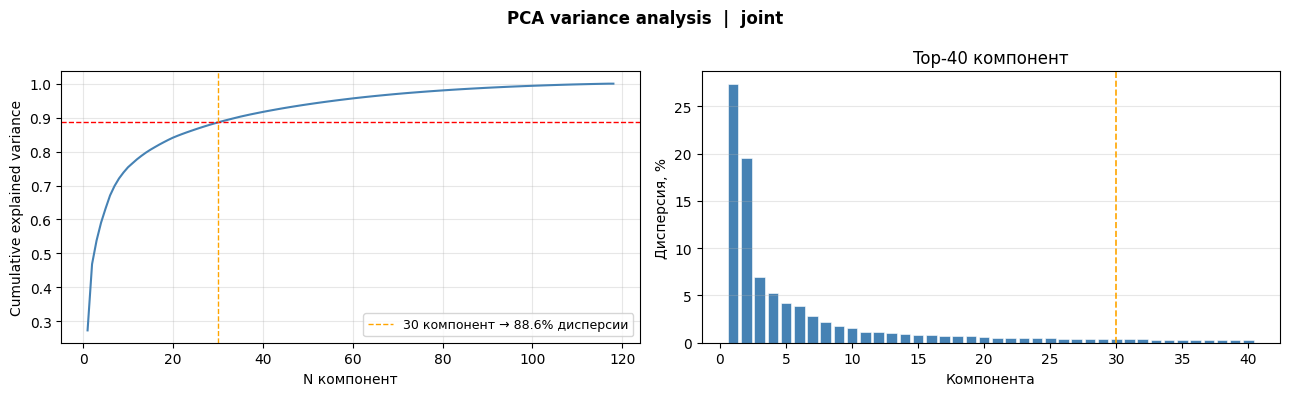

  [joint] n_pca=30  (30 компонент → 88.6% дисперсии)
  F_pca: (118, 30)

=== PCA scatter ===


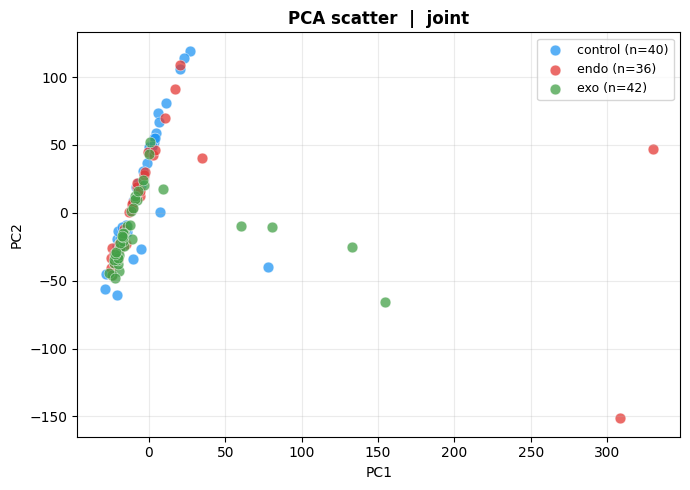


=== LeaveOneGroupOut CV (по animal) ===

────────────────────────────────────────────────────────────
  LOGO CV: joint  |  n=118  фолдов=4  (= животных)
  Классы:   {'exo': 42, 'control': 40, 'endo': 36}
  Животных: {'2a': 36, '2b': 36, '3': 28, '1': 18}
────────────────────────────────────────────────────────────
  LightGBM     | F1_macro=0.4303  [control=0.419  endo=0.308  exo=0.565]
  XGBoost      | F1_macro=0.4154  [control=0.449  endo=0.303  exo=0.494]
  CatBoost     | F1_macro=0.3675  [control=0.372  endo=0.219  exo=0.512]


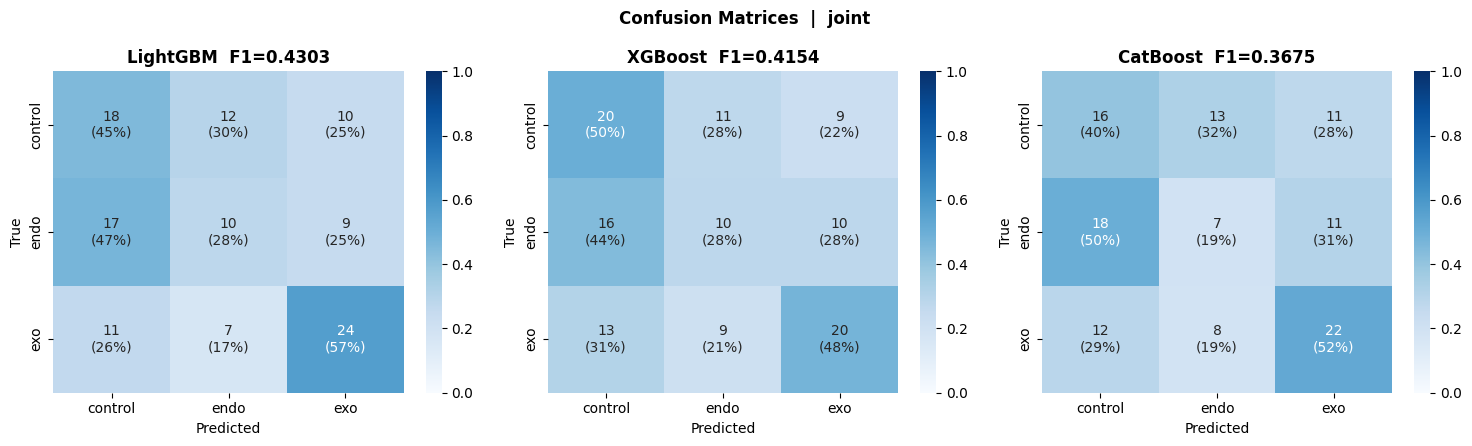


════════════════════════════════════════════════════════════
  Лучшая модель: LightGBM   F1_macro=0.4303
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     control       0.39      0.45      0.42        40
        endo       0.34      0.28      0.31        36
         exo       0.56      0.57      0.56        42

    accuracy                           0.44       118
   macro avg       0.43      0.43      0.43       118
weighted avg       0.44      0.44      0.44       118



In [52]:
"""
=================================================================
Raman Spectra Classification Pipeline  —  v2
=================================================================
Изменения относительно v1:
  - Диапазоны 1500 и 2900 объединяются в одну матрицу признаков
  - LeaveOneGroupOut (LOGO) по animal вместо GroupKFold
  - Модели: LightGBM, XGBoost, CatBoost
  - N_PCA: целое число → число компонент; float < 1 → порог дисперсии

Предполагается наличие X_1500, X_2900, волновых сеток wave_1500, wave_2900
после предобработки (SNV).

map_id формат: label_animal_center_brain_place
=================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# ГЛОБАЛЬНЫЕ КОНСТАНТЫ
# ─────────────────────────────────────────────────────────────

RANDOM_STATE = 42
LABEL_ORDER  = ["control", "endo", "exo"]
LABEL_COLORS = {"control": "#2196F3", "endo": "#E53935", "exo": "#43A047"}

SAVE_DIR = Path("plots")
SAVE_DIR.mkdir(exist_ok=True)

# ── Число главных компонент ─────────────────────────────────
# Целое число (например, 25)  → использовать ровно N компонент
# Float < 1 (например, 0.95)  → минимум компонент для такой доли дисперсии
N_PCA: int | float = 30

# ── Рамановские полосы ──────────────────────────────────────
BANDS_1500 = {
    "Amide_I":    (1620, 1680),   # C=O белков
    "Amide_II":   (1530, 1560),   # N-H + C-N белков
    "CH2_scis":   (1440, 1470),   # ножничные колебания липидов
    "Lipid_1300": (1295, 1320),   # CH2 twist/wag липидов
    "Collagen":   (1240, 1270),   # Amide III (коллаген)
    "DNA_PO4":    (1080, 1100),   # фосфодиэфир ДНК
    "Ring_Phe":   (1000, 1010),   # фенилаланин (маркер белка)
}
BANDS_2900 = {
    "CH2_s":      (2840, 2870),   # симм. CH2 (липиды)
    "CH3_s":      (2870, 2895),   # симм. CH3 (белки/липиды)
    "CH2_as":     (2900, 2940),   # асимм. CH2
    "Fermi_CH2":  (2900, 2960),   # Ферми-резонанс
    "CH3_as":     (2950, 2985),   # асимм. CH3
}

# ─────────────────────────────────────────────────────────────
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ─────────────────────────────────────────────────────────────

def parse_map_id(index: pd.Index) -> pd.DataFrame:
    """
    map_id = label_animal_center_brain_place
    place может содержать '_', поэтому парсим первые 4 поля,
    остальное — place.
    """
    records = []
    for mid in index:
        p = mid.split("_")
        records.append({
            "label":  p[0],
            "animal": p[1],
            "center": p[2],
            "brain":  p[3] if len(p) > 3 else "",
            "place":  "_".join(p[4:]) if len(p) > 4 else "",
        })
    return pd.DataFrame(records, index=index)


def get_base_id(map_id: str) -> str:
    """
    Удаляет поле center из map_id → связующий ключ для объединения диапазонов.
    'endo_2b_1500_striatum_2_4' → 'endo_2b_striatum_2_4'
    """
    p = map_id.split("_")
    return "_".join(p[:2] + p[3:])


# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

def spectral_derivatives(X: pd.DataFrame) -> pd.DataFrame:
    """
    1-я и 2-я производные через np.gradient (центральные разности).
    Помогают выделить смещения и кривизну пиков.
    """
    v  = X.values.astype(np.float64)
    d1 = np.gradient(v, axis=1)
    d2 = np.gradient(d1, axis=1)
    cols = X.columns
    return pd.concat([
        pd.DataFrame(d1, index=X.index, columns=[f"d1_{c}" for c in cols]),
        pd.DataFrame(d2, index=X.index, columns=[f"d2_{c}" for c in cols]),
    ], axis=1)


def band_features(X: pd.DataFrame, bands: dict) -> pd.DataFrame:
    """
    Для каждой полосы: площадь (area), высота (max) и позиция пика (pos).
    """
    wave  = X.columns.astype(float).values
    feats = {}
    for name, (lo, hi) in bands.items():
        mask = (wave >= lo) & (wave <= hi)
        if mask.sum() == 0:
            continue
        reg = X.values[:, mask].astype(np.float64)
        wv  = wave[mask]
        feats[f"area_{name}"] = reg.sum(axis=1)
        feats[f"max_{name}"]  = reg.max(axis=1)
        feats[f"pos_{name}"]  = wv[reg.argmax(axis=1)]
    return pd.DataFrame(feats, index=X.index)


def build_features(X: pd.DataFrame, bands: dict, prefix: str = "") -> pd.DataFrame:
    """
    Итоговая матрица для одного диапазона:
      - SNV-спектр
      - 1-я и 2-я производные
      - band-признаки (area / max / pos)
    prefix — суффикс колонок для различения диапазонов при конкатенации.
    """
    spec  = X.copy()
    deriv = spectral_derivatives(X)
    bands_df = band_features(X, bands)

    if prefix:
        spec.columns     = [f"{prefix}_{c}"  for c in spec.columns]
        deriv.columns    = [f"{prefix}_{c}"  for c in deriv.columns]
        bands_df.columns = [f"{prefix}_{c}"  for c in bands_df.columns]

    return pd.concat([spec, deriv, bands_df], axis=1).astype(np.float32)


# ─────────────────────────────────────────────────────────────
# PCA: ВЫБОР ЧИСЛА КОМПОНЕНТ
# ─────────────────────────────────────────────────────────────

def resolve_n_pca(X_scaled: np.ndarray, n_pca: int | float, title: str = "") -> int:
    """
    Если n_pca — целое число, используется напрямую (но не больше ранга матрицы).
    Если n_pca < 1 (float), вычисляется через кумулятивную дисперсию.
    В обоих случаях строится график.
    """
    max_components = min(X_scaled.shape)

    pca_full = PCA(svd_solver="full").fit(X_scaled)
    cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

    if isinstance(n_pca, float) and n_pca < 1:
        n = int(np.searchsorted(cumvar, n_pca)) + 1
        threshold = n_pca
        mode_label = f"{threshold*100:.0f}% дисперсии → {n} компонент"
    else:
        n = min(int(n_pca), max_components)
        threshold = cumvar[n - 1]
        mode_label = f"{n} компонент → {threshold*100:.1f}% дисперсии"

    n = min(n, max_components)

    # ── График ──────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"PCA variance analysis  |  {title}", fontweight="bold")

    show = min(150, len(cumvar))
    ax1.plot(range(1, show + 1), cumvar[:show], lw=1.5, color="steelblue")
    ax1.axhline(threshold, color="red",    ls="--", lw=1)
    ax1.axvline(n,         color="orange", ls="--", lw=1,
                label=mode_label)
    ax1.set_xlabel("N компонент")
    ax1.set_ylabel("Cumulative explained variance")
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    top = min(40, len(pca_full.explained_variance_ratio_))
    ax2.bar(range(1, top + 1),
            pca_full.explained_variance_ratio_[:top] * 100,
            color="steelblue", edgecolor="white", lw=0.4)
    ax2.axvline(n, color="orange", ls="--", lw=1.2)
    ax2.set_xlabel("Компонента")
    ax2.set_ylabel("Дисперсия, %")
    ax2.set_title(f"Top-{top} компонент")
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    fname = SAVE_DIR / f"pca_variance_{title}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  [{title}] n_pca={n}  ({mode_label})")
    return n


# ─────────────────────────────────────────────────────────────
# ПОСТРОЕНИЕ МОДЕЛЕЙ
# ─────────────────────────────────────────────────────────────

def make_models(n_classes: int) -> dict:
    """
    Три градиентных бустинга.
    Параметры консервативны (малый датасет, склонность к переобучению).
    """
    is_multiclass = n_classes > 2

    models = {
        "LightGBM": lgb.LGBMClassifier(
            n_estimators     = 500,
            learning_rate    = 0.05,
            num_leaves       = 15,
            min_child_samples= 3,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            class_weight     = "balanced",
            random_state     = RANDOM_STATE,
            verbose          = -1,
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators     = 500,
            learning_rate    = 0.05,
            max_depth        = 3,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            objective        = "multi:softprob" if is_multiclass else "binary:logistic",
            num_class        = n_classes if is_multiclass else None,
            eval_metric      = "mlogloss",
            use_label_encoder= False,
            random_state     = RANDOM_STATE,
            verbosity        = 0,
        ),
        "CatBoost": CatBoostClassifier(
            iterations       = 500,
            learning_rate    = 0.05,
            depth            = 4,
            l2_leaf_reg      = 5,
            auto_class_weights="Balanced",
            random_state     = RANDOM_STATE,
            verbose          = False,
        ),
    }
    return models


# ─────────────────────────────────────────────────────────────
# CROSS-VALIDATION  (LeaveOneGroupOut)
# ─────────────────────────────────────────────────────────────

def run_logo_cv(
    F_pca:  np.ndarray,
    y:      pd.Series,
    groups: pd.Series,
    name:   str = "joint",
) -> dict:
    """
    LeaveOneGroupOut по колонке animal.
    Каждый фолд: один animal в test, остальные в train.
    Гарантирует полную изоляцию животных между train/test.

    Возвращает dict[model_name] → {oof_pred, oof_proba, f1_macro, classes}
    """
    logo    = LeaveOneGroupOut()
    classes = sorted(y.unique())
    le      = LabelEncoder().fit(classes)
    y_enc   = le.transform(y.values)

    n_folds = logo.get_n_splits(groups=groups)
    print(f"\n{'─'*60}")
    print(f"  LOGO CV: {name}  |  n={len(y)}  фолдов={n_folds}  (= животных)")
    print(f"  Классы:   {y.value_counts().to_dict()}")
    print(f"  Животных: {groups.value_counts().to_dict()}")
    print(f"{'─'*60}")

    models   = make_models(len(classes))
    results  = {}
    X_arr    = F_pca
    grp_arr  = groups.values

    for model_name, model in models.items():
        oof_proba = np.zeros((len(y), len(classes)), dtype=np.float32)

        for tr_idx, te_idx in logo.split(X_arr, y_enc, grp_arr):
            model.fit(X_arr[tr_idx], y_enc[tr_idx])
            oof_proba[te_idx] = model.predict_proba(X_arr[te_idx])

        oof_pred = le.inverse_transform(oof_proba.argmax(axis=1))

        f1_macro = f1_score(y.values, oof_pred, average="macro")
        f1_per   = f1_score(y.values, oof_pred, average=None, labels=classes)
        tag = "  ".join(f"{c}={f:.3f}" for c, f in zip(classes, f1_per))

        print(f"  {model_name:<12} | F1_macro={f1_macro:.4f}  [{tag}]")

        results[model_name] = {
            "oof_pred":  pd.Series(oof_pred, index=y.index),
            "oof_proba": pd.DataFrame(oof_proba, index=y.index, columns=classes),
            "f1_macro":  f1_macro,
            "classes":   classes,
        }

    return results


# ─────────────────────────────────────────────────────────────
# ВИЗУАЛИЗАЦИЯ
# ─────────────────────────────────────────────────────────────

def plot_pca_scatter(F_pca: np.ndarray, y: pd.Series, title: str):
    """PC1 vs PC2 scatter для визуальной проверки разделимости."""
    pca2   = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(F_pca)
    fig, ax = plt.subplots(figsize=(7, 5))
    for lbl in LABEL_ORDER:
        mask = y.values == lbl
        if mask.sum() == 0:
            continue
        ax.scatter(pca2[mask, 0], pca2[mask, 1],
                   label=f"{lbl} (n={mask.sum()})",
                   color=LABEL_COLORS.get(lbl, "grey"),
                   alpha=0.75, s=60, edgecolors="white", lw=0.4)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"PCA scatter  |  {title}", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"pca_scatter_{title}.png", dpi=130, bbox_inches="tight")
    plt.show()


def plot_confusion_matrices(results: dict, y: pd.Series, title_prefix: str):
    """Confusion matrix (нормированная + абсолютные числа) для каждой модели."""
    classes = sorted(y.unique())
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Confusion Matrices  |  {title_prefix}", fontweight="bold")

    for ax, (model_name, r) in zip(axes, results.items()):
        cm      = confusion_matrix(y, r["oof_pred"], labels=classes)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot   = np.array([[f"{v}\n({p:.0%})"
                             for v, p in zip(rv, rp)]
                            for rv, rp in zip(cm, cm_norm)])
        sns.heatmap(cm_norm, annot=annot, fmt="",
                    cmap="Blues", vmin=0, vmax=1,
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f"{model_name}  F1={r['f1_macro']:.4f}", fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"confusion_{title_prefix}.png", dpi=130, bbox_inches="tight")
    plt.show()


def print_best_report(results: dict, y: pd.Series):
    """Полный classification_report для лучшей по F1 модели."""
    best_name = max(results, key=lambda k: results[k]["f1_macro"])
    best      = results[best_name]
    print(f"\n{'═'*60}")
    print(f"  Лучшая модель: {best_name}   F1_macro={best['f1_macro']:.4f}")
    print(f"{'═'*60}")
    print(classification_report(y, best["oof_pred"],
                                 target_names=best["classes"]))


# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────

# ── 0. Объединение диапазонов ────────────────────────────────
print("=== Объединение диапазонов 1500 и 2900 ===")

X_1500_norm = X_1500.copy()
X_2900_norm = X_2900.copy()
X_1500_norm.index = X_1500_norm.index.map(get_base_id)
X_2900_norm.index = X_2900_norm.index.map(get_base_id)

common_idx = X_1500_norm.index.intersection(X_2900_norm.index)
print(f"  Карт в 1500: {len(X_1500_norm)}  |  в 2900: {len(X_2900_norm)}  |  "
      f"общих: {len(common_idx)}")

X_joint = pd.concat(
    [X_1500_norm.loc[common_idx], X_2900_norm.loc[common_idx]], axis=1
)

# Метаданные берём из исходных индексов X_1500
meta = parse_map_id(X_1500.index)
meta.index = meta.index.map(get_base_id)
y_joint      = meta.loc[common_idx, "label"].astype(str)
groups_joint = meta.loc[common_idx, "animal"].astype(str)

print(f"  X_joint: {X_joint.shape}")
print(f"  Классы:   {y_joint.value_counts().to_dict()}")
print(f"  Животных: {groups_joint.value_counts().to_dict()}")

# ── 1. Feature Engineering ───────────────────────────────────
print("\n=== Feature Engineering ===")

# Признаки строим на исходных SNV-матрицах (без w1500_/w2900_ в именах колонок)
# чтобы band_features корректно матчил диапазоны волн
F_1500_part = build_features(X_1500_norm, BANDS_1500, prefix="f1500")
F_2900_part = build_features(X_2900_norm, BANDS_2900, prefix="f2900")

# Объединяем только по общим индексам
F_joint = pd.concat(
    [F_1500_part.loc[common_idx], F_2900_part.loc[common_idx]], axis=1
)
print(f"  F_joint: {F_joint.shape}")

# ── 2. PCA ───────────────────────────────────────────────────
print(f"\n=== PCA  (N_PCA={N_PCA}) ===")
scaler   = StandardScaler()
F_scaled = scaler.fit_transform(F_joint.values)

n_pca = resolve_n_pca(F_scaled, N_PCA, title="joint")
n_pca = min(n_pca, len(common_idx) - 1)  # не больше n_samples - 1

pca   = PCA(n_components=n_pca, random_state=RANDOM_STATE)
F_pca = pca.fit_transform(F_scaled)
print(f"  F_pca: {F_pca.shape}")

# ── 3. PCA scatter (визуальный санити-чек) ───────────────────
print("\n=== PCA scatter ===")
plot_pca_scatter(F_pca, y_joint, title="joint")

# ── 4. LOGO Cross-Validation ─────────────────────────────────
print("\n=== LeaveOneGroupOut CV (по animal) ===")
results = run_logo_cv(F_pca, y_joint, groups_joint, name="joint")

# ── 5. Confusion matrices ────────────────────────────────────
plot_confusion_matrices(results, y_joint, title_prefix="joint")

# ── 6. Лучшая модель — полный отчёт ─────────────────────────
print_best_report(results, y_joint)

In [53]:
X_joint

,926.8300170898438,927.5474620612961,928.2649070327484,928.9823520042007,929.699796975653,930.4172419471054,931.1346869185577,931.85213189001,932.5695768614623,933.2870218329147,...,3283.1320680258195,3283.6851835142697,3284.2382990027204,3284.791414491171,3285.3445299796217,3285.8976454680724,3286.450760956523,3287.0038764449737,3287.5569919334243,3288.110107421875
map_id,,,,,,,,,,,,,,,,,,,,,
control_1_cortex_4_1,-0.421913,-0.418108,-0.414037,-0.409400,-0.403898,-0.397229,-0.369347,-0.361729,-0.374939,-0.386995,...,-0.381065,-0.417586,-0.464628,-0.465815,-0.485290,-0.483162,-0.468357,-0.439762,-0.396268,-0.336762
control_1_cortex_4_2,-0.349387,-0.387441,-0.421929,-0.451069,-0.473079,-0.486175,-0.460331,-0.446703,-0.450630,-0.454836,...,-0.377570,-0.411169,-0.456181,-0.444624,-0.461264,-0.464848,-0.456559,-0.432873,-0.390266,-0.325214
control_1_cortex_5_1,-0.369849,-0.343358,-0.334328,-0.337266,-0.346676,-0.357064,-0.339758,-0.327012,-0.324173,-0.324366,...,-0.393818,-0.406815,-0.428031,-0.425401,-0.443422,-0.451441,-0.450445,-0.437015,-0.407730,-0.359168
control_1_cortex_5_2,-0.345518,-0.313995,-0.302487,-0.305897,-0.319127,-0.337080,-0.336398,-0.346009,-0.363126,-0.369933,...,-0.357191,-0.380351,-0.412540,-0.414906,-0.432653,-0.437660,-0.432860,-0.415892,-0.384397,-0.336014
control_1_cortex_6_1,-0.347693,-0.341139,-0.339028,-0.339465,-0.340559,-0.340414,-0.317478,-0.306050,-0.308808,-0.311980,...,-0.336005,-0.346307,-0.370415,-0.378884,-0.396724,-0.409420,-0.415960,-0.413663,-0.399848,-0.371834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
exo_3_cerebellum_right_1_4,-0.345907,-0.353413,-0.358538,-0.361341,-0.361879,-0.360212,-0.342217,-0.337044,-0.344533,-0.357693,...,-0.325592,-0.334296,-0.344467,-0.351516,-0.358167,-0.361962,-0.361044,-0.353890,-0.338975,-0.314774
exo_3_cerebellum_right_2_2,-0.394668,-0.378862,-0.368601,-0.362558,-0.359404,-0.357812,-0.344762,-0.344472,-0.352888,-0.355889,...,-0.313623,-0.339101,-0.368033,-0.386397,-0.411560,-0.431393,-0.440810,-0.435344,-0.410528,-0.361897
exo_3_cerebellum_right_2_4,-0.384190,-0.392324,-0.397062,-0.398453,-0.396549,-0.391399,-0.370004,-0.362194,-0.363631,-0.356708,...,-0.339663,-0.361174,-0.385217,-0.399699,-0.424738,-0.437720,-0.438192,-0.421793,-0.384165,-0.320945
